In [1]:
import pandas as pd
import numpy as np

transactions = pd.read_csv('../data/train_transaction.csv')
identity = pd.read_csv('../data/train_identity.csv')

print("Transactions shape:", transactions.shape)
print("Identity shape:", identity.shape)
print("\nFraud rate:", transactions['isFraud'].mean() * 100, "%")
print("\nTransaction columns:", transactions.shape[1])
print("Identity columns:", identity.shape[1])

Transactions shape: (590540, 394)
Identity shape: (144233, 41)

Fraud rate: 3.4990009144173126 %

Transaction columns: 394
Identity columns: 41


In [2]:
# Check missing values
missing = transactions.isnull().sum() / len(transactions) * 100
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing data (top 20):")
print(missing.head(20))

print("\nFirst few non-V columns:")
non_v_cols = [c for c in transactions.columns if not c.startswith('V')]
print(non_v_cols)

Columns with missing data (top 20):
dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V157     86.123717
V163     86.123717
V162     86.123717
V161     86.123717
V158     86.123717
V153     86.123717
V138     86.123717
V155     86.123717
V154     86.123717
V149     86.123717
V148     86.123717
V147     86.123717
dtype: float64

First few non-V columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [4]:
# Look at the non-anonymized columns we can actually explain
non_v_cols = [c for c in transactions.columns if not c.startswith('V')]
print("Non-anonymized columns:")
for col in non_v_cols:
    print(f"  {col}: {transactions[col].dtype} | missing: {transactions[col].isnull().sum()/len(transactions)*100:.1f}%")

Non-anonymized columns:
  TransactionID: int64 | missing: 0.0%
  isFraud: int64 | missing: 0.0%
  TransactionDT: int64 | missing: 0.0%
  TransactionAmt: float64 | missing: 0.0%
  ProductCD: str | missing: 0.0%
  card1: int64 | missing: 0.0%
  card2: float64 | missing: 1.5%
  card3: float64 | missing: 0.3%
  card4: str | missing: 0.3%
  card5: float64 | missing: 0.7%
  card6: str | missing: 0.3%
  addr1: float64 | missing: 11.1%
  addr2: float64 | missing: 11.1%
  dist1: float64 | missing: 59.7%
  dist2: float64 | missing: 93.6%
  P_emaildomain: str | missing: 16.0%
  R_emaildomain: str | missing: 76.8%
  C1: float64 | missing: 0.0%
  C2: float64 | missing: 0.0%
  C3: float64 | missing: 0.0%
  C4: float64 | missing: 0.0%
  C5: float64 | missing: 0.0%
  C6: float64 | missing: 0.0%
  C7: float64 | missing: 0.0%
  C8: float64 | missing: 0.0%
  C9: float64 | missing: 0.0%
  C10: float64 | missing: 0.0%
  C11: float64 | missing: 0.0%
  C12: float64 | missing: 0.0%
  C13: float64 | missing: 0

In [6]:
# Merge transactions with identity data
df = transactions.merge(identity, on='TransactionID', how='left')

print("Merged shape:", df.shape)

# Fraud rate by product type
print("\nFraud rate by ProductCD:")
print(df.groupby('ProductCD')['isFraud'].agg(['mean', 'count']).round(3))

# Fraud rate by card type
print("\nFraud rate by card4 (card network):")
print(df.groupby('card4')['isFraud'].agg(['mean', 'count']).round(3))

Merged shape: (590540, 434)

Fraud rate by ProductCD:
            mean   count
ProductCD               
C          0.117   68519
H          0.048   33024
R          0.038   37699
S          0.059   11628
W          0.020  439670

Fraud rate by card4 (card network):
                   mean   count
card4                          
american express  0.029    8328
discover          0.077    6651
mastercard        0.034  189217
visa              0.035  384767


In [8]:
# Feature engineering — turning raw columns into meaningful signals

df = df.copy()

# 1. Extract hour from TransactionDT (fraud spikes at night)
# TransactionDT is seconds since reference — we extract hour of day
df['transaction_hour'] = (df['TransactionDT'] // 3600) % 24
df['transaction_day'] = (df['TransactionDT'] // (3600 * 24)) % 7

# 2. Flag high-risk email domains
risky_domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'anonymous.com']
df['is_risky_email'] = df['P_emaildomain'].isin(risky_domains).astype(int)

# 3. Log transform transaction amount (skewed distribution)
df['log_amount'] = np.log1p(df['TransactionAmt'])

# 4. Card mismatch signal — card3 and card5 being unusual
df['card_mismatch'] = ((df['card3'] != df['card3'].mode()[0]) | 
                        (df['card5'] != df['card5'].mode()[0])).astype(int)

# 5. Check fraud rate by hour
print("Fraud rate by hour of day:")
hourly_fraud = df.groupby('transaction_hour')['isFraud'].mean()
print(hourly_fraud.round(3).to_string())

Fraud rate by hour of day:
transaction_hour
0     0.031
1     0.031
2     0.037
3     0.038
4     0.052
5     0.070
6     0.078
7     0.106
8     0.093
9     0.090
10    0.053
11    0.039
12    0.030
13    0.023
14    0.024
15    0.025
16    0.030
17    0.032
18    0.035
19    0.035
20    0.034
21    0.034
22    0.033
23    0.037


In [9]:
# Defragment first
df = df.copy()

# Select our final feature set — columns we can explain
features = [
    # Transaction signals
    'TransactionAmt', 'log_amount', 'transaction_hour', 'transaction_day',
    
    # Product and card signals  
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    
    # Address signals
    'addr1', 'addr2',
    
    # Count features (how many cards/addresses associated with this user)
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    
    # Time delta features (days since last transaction etc)
    'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15',
    
    # Match features
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6',
    
    # Our engineered features
    'is_risky_email', 'card_mismatch'
]

target = 'isFraud'

# Handle categorical columns — convert to numeric codes
cat_cols = ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6']
for col in cat_cols:
    if col in features:
        df[col] = pd.Categorical(df[col]).codes

# Fill missing values with -1 (XGBoost handles this natively)
X = df[features].fillna(-1)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"\nReady to train on {X.shape[0]:,} transactions with {X.shape[1]} features")

Feature matrix shape: (590540, 43)
Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Ready to train on 590,540 transactions with 43 features


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

# Split into train and test sets
# 80% train, 20% test — test set is data the model never sees during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Test set: {X_test.shape[0]:,} transactions")
print(f"\nFraud rate in train: {y_train.mean()*100:.2f}%")
print(f"Fraud rate in test: {y_test.mean()*100:.2f}%")

# Calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.1f}")
print("(This tells XGBoost to treat each fraud case as 27x more important)")

Training set: 472,432 transactions
Test set: 118,108 transactions

Fraud rate in train: 3.50%
Fraud rate in test: 3.50%

scale_pos_weight: 27.6
(This tells XGBoost to treat each fraud case as 27x more important)


In [14]:
import xgboost as xgb

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=500,        # number of trees to build
    max_depth=6,             # how deep each tree can go
    learning_rate=0.05,      # how much each tree corrects the previous
    scale_pos_weight=27.6,   # handle class imbalance
    subsample=0.8,           # use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree (prevents overfitting)
    random_state=42,
    eval_metric='aucpr',     # optimize for precision-recall AUC
    early_stopping_rounds=50 # stop if no improvement after 50 rounds
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # print progress every 50 trees
)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr = average_precision_score(y_test, y_pred_proba)

print(f"\nAUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR (Precision-Recall): {auc_pr:.4f}")
print("\nAUC-ROC > 0.90 = excellent for fraud detection")
print("AUC-PR > 0.70 = excellent given 3.5% fraud rate")

[0]	validation_0-aucpr:0.37781
[50]	validation_0-aucpr:0.49190
[100]	validation_0-aucpr:0.53898
[150]	validation_0-aucpr:0.56360
[200]	validation_0-aucpr:0.58075
[250]	validation_0-aucpr:0.59348
[300]	validation_0-aucpr:0.60637
[350]	validation_0-aucpr:0.61859
[400]	validation_0-aucpr:0.62789
[450]	validation_0-aucpr:0.63663
[499]	validation_0-aucpr:0.64461

AUC-ROC: 0.9434
AUC-PR (Precision-Recall): 0.6447

AUC-ROC > 0.90 = excellent for fraud detection
AUC-PR > 0.70 = excellent given 3.5% fraud rate


Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


Top 15 most important features:
  feature  importance
       C8    0.207787
       C4    0.078667
      C14    0.064753
       C5    0.045625
    card6    0.042719
       M4    0.039747
       D3    0.035532
       C1    0.030930
      C12    0.024452
    addr2    0.024385
      C11    0.021695
ProductCD    0.021113
       D2    0.020485
      C13    0.019856
       M5    0.019304


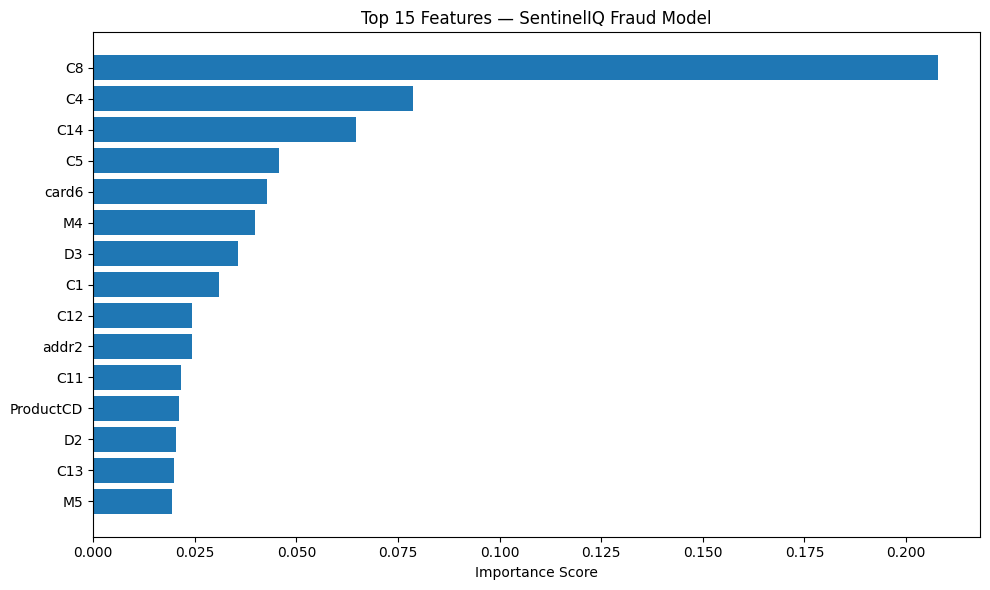


Plot saved to data/feature_importance.png


In [16]:
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance.head(15)['feature'][::-1], 
         importance.head(15)['importance'][::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Features — SentinelIQ Fraud Model')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()
print("\nPlot saved to data/feature_importance.png")

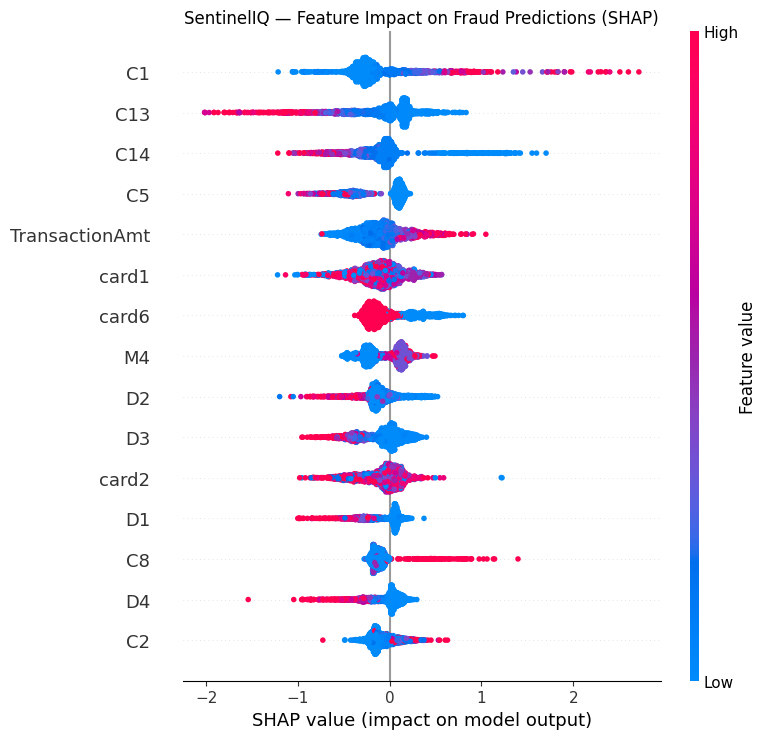

SHAP plot saved


In [17]:
import shap

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on a sample (full dataset takes too long)
X_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot — shows impact of each feature on model output
shap.summary_plot(shap_values, X_sample, 
                  feature_names=features,
                  max_display=15,
                  show=False)
plt.title("SentinelIQ — Feature Impact on Fraud Predictions (SHAP)")
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved")

In [18]:
import pickle
import os

# Save the model
os.makedirs('../models', exist_ok=True)
with open('../models/sentineliq_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the feature list
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Model saved to models/sentineliq_model.pkl")

# Now load data into PostgreSQL
from sqlalchemy import create_engine

# Connection string — no password since we set none
engine = create_engine('postgresql://vatsalj05@localhost:5432/sentineliq')

# Load a sample of transactions into the database
# (full 590k would take too long — 50k is plenty for the project)
print("\nLoading 50,000 transactions into PostgreSQL...")
df_sample = df.sample(50000, random_state=42).copy()

# Prepare the transactions table columns
db_transactions = df_sample[[
    'TransactionID', 'TransactionAmt', 'ProductCD', 
    'card1', 'card4', 'card6', 'addr1', 'addr2',
    'transaction_hour', 'transaction_day',
    'is_risky_email', 'card_mismatch',
    'C1', 'C2', 'C8', 'C13', 'C14',
    'D1', 'D2', 'D3', 'isFraud'
]].copy()

db_transactions.columns = [
    'transaction_id', 'amount', 'product_type',
    'card1', 'card4', 'card6', 'addr1', 'addr2',
    'transaction_hour', 'transaction_day',
    'is_risky_email', 'card_mismatch',
    'c1', 'c2', 'c8', 'c13', 'c14',
    'd1', 'd2', 'd3', 'is_fraud'
]

db_transactions.to_sql('transactions_raw', engine, 
                        if_exists='replace', index=False)
print("✓ 50,000 transactions loaded into PostgreSQL")
print("\nNow run this in psql to verify:")
print("SELECT COUNT(*), AVG(is_fraud) FROM transactions_raw;")

Model saved to models/sentineliq_model.pkl

Loading 50,000 transactions into PostgreSQL...
✓ 50,000 transactions loaded into PostgreSQL

Now run this in psql to verify:
SELECT COUNT(*), AVG(is_fraud) FROM transactions_raw;


In [19]:
import random
from sqlalchemy import text

# Generate synthetic breach exposure profiles
# Based on realistic post-breach scenarios in Canadian fintech
random.seed(42)
np.random.seed(42)

# Get unique transaction IDs from our sample as proxy client IDs
client_ids = df_sample['TransactionID'].astype(str).tolist()

# Simulate a breach affecting 30% of clients (realistic for a major incident)
breached_clients = random.sample(client_ids, k=int(len(client_ids) * 0.30))

exposure_records = []
for client_id in client_ids:
    if client_id in breached_clients:
        # What data was exposed — different clients had different data exposed
        sin_exposed = random.random() < 0.6        # 60% had SIN exposed
        dob_exposed = random.random() < 0.7        # 70% had DOB exposed
        account_exposed = random.random() < 0.5    # 50% had account number exposed
        ip_exposed = random.random() < 0.4         # 40% had IP exposed
        gov_id_exposed = random.random() < 0.3     # 30% had government ID exposed
        
        # Calculate exposure score — more fields exposed = higher risk
        exposure_score = (
            sin_exposed * 0.35 +      # SIN is most dangerous
            gov_id_exposed * 0.25 +   # Government ID second
            account_exposed * 0.20 +  # Account number third
            dob_exposed * 0.12 +      # DOB fourth
            ip_exposed * 0.08         # IP least dangerous alone
        )
    else:
        sin_exposed = dob_exposed = account_exposed = ip_exposed = gov_id_exposed = False
        exposure_score = 0.0

    exposure_records.append({
        'client_id': client_id,
        'sin_exposed': sin_exposed,
        'dob_exposed': dob_exposed,
        'account_number_exposed': account_exposed,
        'ip_exposed': ip_exposed,
        'government_id_exposed': gov_id_exposed,
        'exposure_date': '2025-08-15',  # Wealthsimple breach date
        'exposure_score': round(exposure_score, 4)
    })

# Load into PostgreSQL
exposure_df = pd.DataFrame(exposure_records)
exposure_df.to_sql('exposure_profiles', engine, 
                   if_exists='replace', index=False)

print(f"✓ {len(exposure_records):,} exposure profiles loaded")
print(f"✓ {len(breached_clients):,} clients affected by breach ({len(breached_clients)/len(client_ids)*100:.0f}%)")
print(f"\nExposure score distribution:")
print(exposure_df[exposure_df['exposure_score'] > 0]['exposure_score'].describe().round(3))

✓ 50,000 exposure profiles loaded
✓ 15,000 clients affected by breach (30%)

Exposure score distribution:
count    14612.000
mean         0.515
std          0.228
min          0.080
25%          0.350
50%          0.550
75%          0.670
max          1.000
Name: exposure_score, dtype: float64


In [20]:
# Generate fraud probability scores for all 50,000 clients
# using our trained XGBoost model

# Get the features for our sample
X_scoring = df_sample[features].fillna(-1)

# Get fraud probabilities
fraud_probs = model.predict_proba(X_scoring)[:, 1]

# Build composite risk scores
risk_records = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    client_id = str(row['TransactionID'])
    fraud_prob = float(fraud_probs[i])
    
    # Get exposure score for this client
    exp_record = exposure_df[exposure_df['client_id'] == client_id]
    exposure_score = float(exp_record['exposure_score'].values[0]) if len(exp_record) > 0 else 0.0
    
    # Composite score — weighted combination
    # 70% fraud model, 30% breach exposure
    # Rationale: model signal is stronger but exposure adds meaningful risk
    composite = round(0.70 * fraud_prob + 0.30 * exposure_score, 4)
    
    # Risk tier — what action to take
    if composite >= 0.70:
        tier = 'FREEZE'    # Immediate account freeze, manual review
    elif composite >= 0.45:
        tier = 'ALERT'     # Flag for review, step-up authentication
    elif composite >= 0.20:
        tier = 'MONITOR'   # Enhanced monitoring, no action yet
    else:
        tier = 'CLEAR'     # Normal, no action needed

    risk_records.append({
        'client_id': client_id,
        'fraud_probability': round(fraud_prob, 4),
        'exposure_risk': round(exposure_score, 4),
        'composite_score': composite,
        'risk_tier': tier
    })

risk_df = pd.DataFrame(risk_records)
risk_df.to_sql('risk_scores', engine, if_exists='replace', index=False)

print("✓ Risk scores computed and loaded into PostgreSQL")
print(f"\nRisk tier distribution:")
print(risk_df['risk_tier'].value_counts())
print(f"\nSample high-risk clients:")
print(risk_df[risk_df['risk_tier'] == 'FREEZE'].head(5)[
    ['client_id', 'fraud_probability', 'exposure_risk', 'composite_score', 'risk_tier']
])

✓ Risk scores computed and loaded into PostgreSQL

Risk tier distribution:
risk_tier
CLEAR      31415
MONITOR    13756
ALERT       4189
FREEZE       640
Name: count, dtype: int64

Sample high-risk clients:
    client_id  fraud_probability  exposure_risk  composite_score risk_tier
417   3353286             0.9065           0.72           0.8505    FREEZE
581   3446130             0.8726           0.72           0.8268    FREEZE
623   3160127             0.5975           1.00           0.7183    FREEZE
627   3405217             0.9964           0.12           0.7335    FREEZE
734   3215502             0.7241           0.80           0.7469    FREEZE


In [21]:
# Reload transactions_raw with ALL model features
df_db = df_sample[features + ['TransactionID', 'isFraud']].copy()
df_db.columns = [c.lower() for c in df_db.columns]  # lowercase all column names

df_db.to_sql('transactions_raw', engine, if_exists='replace', index=False)
print("✓ transactions_raw reloaded with all model features")
print("Columns now in DB:", list(df_db.columns))

✓ transactions_raw reloaded with all model features
Columns now in DB: ['transactionamt', 'log_amount', 'transaction_hour', 'transaction_day', 'productcd', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11', 'c12', 'c13', 'c14', 'd1', 'd2', 'd3', 'd4', 'd5', 'd10', 'd11', 'd15', 'm1', 'm2', 'm3', 'm4', 'm5', 'm6', 'is_risky_email', 'card_mismatch', 'transactionid', 'isfraud']


In [24]:
# Test Neon connection and migrate all data
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv('../.env')
NEON_URL = os.getenv('DATABASE_URL')
neon_engine = create_engine(NEON_URL)

# Test connection
with neon_engine.connect() as conn:
    result = pd.read_sql("SELECT version()", conn)
    print("✓ Connected to Neon!")
    print(result.iloc[0, 0])

✓ Connected to Neon!
PostgreSQL 17.8 (ad62774) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit


In [25]:
from sqlalchemy import create_engine
import pandas as pd

local_engine = create_engine('postgresql://vatsalj05@localhost:5432/sentineliq')

# Read all tables from local DB
print("Reading local data...")
with local_engine.connect() as conn:
    transactions = pd.read_sql("SELECT * FROM transactions_raw", conn)
    exposure = pd.read_sql("SELECT * FROM exposure_profiles", conn)
    risk_scores = pd.read_sql("SELECT * FROM risk_scores", conn)
    smart_risk = pd.read_sql("SELECT * FROM smart_risk_scores", conn)
    clv = pd.read_sql("SELECT * FROM clv_scores", conn)
    drift = pd.read_sql('SELECT * FROM drift_monitor', conn)

print(f"✓ transactions_raw: {len(transactions):,} rows")
print(f"✓ exposure_profiles: {len(exposure):,} rows")
print(f"✓ risk_scores: {len(risk_scores):,} rows")
print(f"✓ smart_risk_scores: {len(smart_risk):,} rows")
print(f"✓ clv_scores: {len(clv):,} rows")
print(f"✓ drift_monitor: {len(drift):,} rows")

# Write all to Neon
print("\nMigrating to Neon...")
transactions.to_sql('transactions_raw', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ transactions_raw migrated")
exposure.to_sql('exposure_profiles', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ exposure_profiles migrated")
risk_scores.to_sql('risk_scores', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ risk_scores migrated")
smart_risk.to_sql('smart_risk_scores', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ smart_risk_scores migrated")
clv.to_sql('clv_scores', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ clv_scores migrated")
drift.to_sql('drift_monitor', neon_engine, if_exists='replace', index=False, chunksize=1000)
print("✓ drift_monitor migrated")

print("\n🎉 All data migrated to Neon!")

Reading local data...
✓ transactions_raw: 50,000 rows
✓ exposure_profiles: 50,000 rows
✓ risk_scores: 50,000 rows
✓ smart_risk_scores: 50,000 rows
✓ clv_scores: 5,657 rows
✓ drift_monitor: 8 rows

Migrating to Neon...
✓ transactions_raw migrated
✓ exposure_profiles migrated
✓ risk_scores migrated
✓ smart_risk_scores migrated
✓ clv_scores migrated
✓ drift_monitor migrated

🎉 All data migrated to Neon!
